In [7]:
import json
import math
import os
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import wandb

# Use CUDA when available, otherwise CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
with open('train_r2r_img_motion_cleaned_sorted.json', 'r') as f:
    raw_data = json.load(f)

def clean_motion(seq):
    seq = list(seq)
    if seq and seq[0] == 0:
        seq = seq[1:]
    return seq

# Deduplicate FIRST, keeping one representative per unique sequence
seen = set()
motions = []
for item in raw_data:
    cleaned = clean_motion(item['motion'])
    key = tuple(cleaned)
    if key not in seen:
        seen.add(key)
        motions.append(cleaned)

print(f'After dedup: {len(motions)} unique sequences')
# Then split happens in Cell 4 on these 3,600 unique sequences
# → no test sequence can be a duplicate of any train sequence

After dedup: 3600 unique sequences


In [9]:
# ── Convert Actions to Features ────────────────────────────────────────────
STOP = 0
FORWARD = 1
TURN_LEFT = 2
TURN_RIGHT = 3

step_m = 0.25
turn_rad = math.radians(15.0)

def actions_to_features(action_seq, theta0=0.0):
    """
    7-dim features: cumulative world (x,y), heading (sin,cos), dyaw, is_forward, is_turn
    The key addition is cumulative x,y — makes every timestep unique even during long forward runs.
    """
    theta = theta0
    cum_x, cum_y = 0.0, 0.0
    feat_rows = []

    for a in action_seq:
        dx_local = 0.0
        dyaw = 0.0

        if a == FORWARD:
            dx_local = step_m           
        elif a == TURN_LEFT:
            dyaw = turn_rad
        elif a == TURN_RIGHT:
            dyaw = -turn_rad

        theta += dyaw
        cum_x += dx_local * math.cos(theta)
        cum_y += dx_local * math.sin(theta)

        feat_rows.append([
            cum_x,
            cum_y,
            math.sin(theta),
            math.cos(theta),
            dyaw,
            1.0 if a == FORWARD else 0.0,
            1.0 if a in (TURN_LEFT, TURN_RIGHT) else 0.0,
        ])

    return torch.tensor(feat_rows, dtype=torch.float32)

# Convert trajectories to features
motion_feature_tensors = [actions_to_features(seq) for seq in motions]

# Pad to create batch
padded_motion_features = torch.nn.utils.rnn.pad_sequence(
    motion_feature_tensors, batch_first=True, padding_value=0.0
)
seq_lengths = torch.tensor([t.size(0) for t in motion_feature_tensors], dtype=torch.long)

print(f"\nConverted trajectories: {len(motion_feature_tensors)}")
print(f"First trajectory shape: {motion_feature_tensors[0].shape}")
print(f"Padded batch shape: {padded_motion_features.shape}")
print(f"Sequence lengths (first 10): {seq_lengths[:10]}")



Converted trajectories: 3600
First trajectory shape: torch.Size([38, 7])
Padded batch shape: torch.Size([3600, 500, 7])
Sequence lengths (first 10): tensor([38, 42, 45, 95, 64, 50, 55, 47, 66, 42])


In [10]:
# ── Prepare Data Batch ────────────────────────────────────────────────────
# Create motion batch dict
features = padded_motion_features  # [B, T_max, 3]
lengths = seq_lengths              # [B]

motion_batch = {
    "features": features,
    "lengths": lengths,
}

print(f"Motion batch prepared:")
print(f"  Features shape: {motion_batch['features'].shape}")
print(f"  Lengths shape: {motion_batch['lengths'].shape}")


Motion batch prepared:
  Features shape: torch.Size([3600, 500, 7])
  Lengths shape: torch.Size([3600])


In [11]:
# ── CRITICAL: Train/Test Split (Trajectory Level) ─────────────────────────
# Split BEFORE training to avoid data leakage!

def split_trajectories(sequences, lengths, train_ratio=0.8, seed=42):
    """
    Split trajectories at trajectory level (not timestep level).
    No train/test leakage: each trajectory goes to train or test, never both.
    """
    random.seed(seed)
    torch.manual_seed(seed)
    
    N = sequences.shape[0]
    indices = list(range(N))
    random.shuffle(indices)
    
    split_point = int(N * train_ratio)
    train_indices = sorted(indices[:split_point])
    test_indices = sorted(indices[split_point:])
    
    train_sequences = sequences[train_indices]
    train_lengths = lengths[train_indices]
    test_sequences = sequences[test_indices]
    test_lengths = lengths[test_indices]
    
    print(f"\nTRAIN/TEST SPLIT (trajectory-level):")
    print(f"  Train: {len(train_indices)} trajectories")
    print(f"  Test:  {len(test_indices)} trajectories")
    
    return train_sequences, train_lengths, test_sequences, test_lengths, train_indices, test_indices

# Keep split params explicit for reporting
split_train_ratio = 0.8
split_seed = 42

# Apply split to motion batch
train_seqs, train_lens, test_seqs, test_lens, train_idx, test_idx = split_trajectories(
    motion_batch["features"],
    motion_batch["lengths"],
    train_ratio=split_train_ratio,
    seed=split_seed
)

# Move split tensors to selected device
train_seqs = train_seqs.to(device)
train_lens = train_lens.to(device)
test_seqs = test_seqs.to(device)
test_lens = test_lens.to(device)

print(f"  Train shapes: {train_seqs.shape}, {train_lens.shape}")
print(f"  Test shapes:  {test_seqs.shape}, {test_lens.shape}")
print(f"  Train/Test tensors moved to: {device}")


TRAIN/TEST SPLIT (trajectory-level):
  Train: 2880 trajectories
  Test:  720 trajectories
  Train shapes: torch.Size([2880, 500, 7]), torch.Size([2880])
  Test shapes:  torch.Size([720, 500, 7]), torch.Size([720])
  Train/Test tensors moved to: cuda


In [12]:
# ── GRU Encoder ────────────────────────────────────────────────────────────
import torch.nn as nn

class GRUEncoder(nn.Module):
    """
    Minimal GRU encoder for variable-length trajectories.
    
    Input:  [B, T, D] padded sequences + [B] lengths
    Output: [B, H] L2-normalized embeddings
    
    Pipeline:
      pack_padded_sequence → GRU → final hidden → projection → L2-norm
    """
    def __init__(self, input_dim, hidden_dim, embedding_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.embedding_dim = embedding_dim
        
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )
    
    def forward(self, sequences, lengths):
        """
        Args:
            sequences: [B, T, D] padded tensor
            lengths:   [B] actual lengths
        Returns:
            embeddings: [B, H] L2-normalized
        """
        packed = nn.utils.rnn.pack_padded_sequence(
            sequences, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_output, hidden = self.gru(packed)
        hidden = hidden.squeeze(0)  # [B, hidden_dim]
        embeddings = self.proj(hidden)  # [B, embedding_dim]
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return embeddings

print("GRUEncoder defined")


GRUEncoder defined


In [13]:
# ── Multi-Prefix Sampler ──────────────────────────────────────────────────
def sample_prefix_future_pairs(
    sequences, lengths,
    min_prefix_len=1,
    min_future_len=5,   # NEW: minimum future length
    max_future_len=25,  # NEW: maximum future length  
    max_prefixes_per_traj=None, w_min=0.3,
    return_traj_ids=True,
):
    B, _, D = sequences.shape
    device = sequences.device

    prefix_seqs_list, future_seqs_list = [], []
    prefix_lengths_list, future_lengths_list, weights_list = [], [], []
    traj_ids_list = []

    for i in range(B):
        L_i = lengths[i].item()

        # sample a random future length each time
        future_len = random.randint(min_future_len, max_future_len)
        max_prefix_end = L_i - future_len

        if max_prefix_end < min_prefix_len:
            continue

        valid_ends = list(range(min_prefix_len, max_prefix_end + 1))
        if max_prefixes_per_traj:
            sampled_ends = random.sample(valid_ends, min(len(valid_ends), max_prefixes_per_traj))
        else:
            sampled_ends = valid_ends

        for t in sampled_ends:
            prefix_seqs_list.append(sequences[i, 0:t, :])
            prefix_lengths_list.append(t)

            future_end = min(t + future_len, L_i)
            future_seqs_list.append(sequences[i, t:future_end, :])
            future_lengths_list.append(future_end - t)

            progress = (t - min_prefix_len) / max(1, L_i - future_len - min_prefix_len)
            progress = max(0.0, min(1.0, progress))
            weight = w_min + (1 - w_min) * progress
            weights_list.append(weight)

            if return_traj_ids:
                traj_ids_list.append(i)

    if prefix_seqs_list:
        prefix_seqs = nn.utils.rnn.pad_sequence(prefix_seqs_list, batch_first=True, padding_value=0.0)
        future_seqs = nn.utils.rnn.pad_sequence(future_seqs_list, batch_first=True, padding_value=0.0)
        prefix_lengths = torch.tensor(prefix_lengths_list, dtype=torch.long, device=device)
        future_lengths = torch.tensor(future_lengths_list, dtype=torch.long, device=device)
        weights = torch.tensor(weights_list, dtype=torch.float32, device=device)
        traj_ids = torch.tensor(traj_ids_list, dtype=torch.long, device=device) if return_traj_ids else None
    else:
        prefix_seqs = torch.zeros((0, 1, D), dtype=sequences.dtype, device=device)
        future_seqs = torch.zeros((0, future_len, D), dtype=sequences.dtype, device=device)
        prefix_lengths = torch.zeros((0,), dtype=torch.long, device=device)
        future_lengths = torch.zeros((0,), dtype=torch.long, device=device)
        weights = torch.zeros((0,), dtype=torch.float32, device=device)
        traj_ids = torch.zeros((0,), dtype=torch.long, device=device) if return_traj_ids else None

    return prefix_seqs, future_seqs, prefix_lengths, future_lengths, weights, traj_ids

print("Sampler defined")

Sampler defined


### Why This Masking Fix Is Needed

Training now uses multiple sampled prefix/future pairs per trajectory, which improves supervision per epoch.

When multiple pairs come from the same trajectory, those off-diagonal similarities should not be treated as negatives. They are semantically related, not true negatives.

So the InfoNCE logits are masked to ignore same-trajectory off-diagonal entries while keeping diagonal positives and different-trajectory negatives. This keeps the stronger multi-prefix signal without introducing contradictory negative labels.

In [14]:
# ── Masked InfoNCE Loss with Weights ───────────────────────────────────────
def apply_same_trajectory_mask(logits, traj_ids):
    """
    Mask same-trajectory off-diagonal pairs so they are not treated as negatives.
    Keeps diagonal positives intact.
    """
    if traj_ids is None or logits.numel() == 0:
        return logits

    same_traj = traj_ids.unsqueeze(1) == traj_ids.unsqueeze(0)
    eye = torch.eye(logits.size(0), dtype=torch.bool, device=logits.device)
    invalid = same_traj & (~eye)
    return logits.masked_fill(invalid, -1e9)


def infonce_loss(z_prefix, z_future, weights, temperature=0.1, traj_ids=None):
    """
    Weighted InfoNCE loss for trajectory similarity learning.

    Diagonal of similarity matrix = positive pairs (same sampled pair).
    Negatives are only from different trajectories; same-trajectory off-diagonal pairs are masked.
    """
    logits = torch.matmul(z_prefix, z_future.T) / temperature  # [M, M]
    logits = apply_same_trajectory_mask(logits, traj_ids)

    targets = torch.arange(logits.size(0), device=logits.device)
    loss_per_sample = torch.nn.functional.cross_entropy(logits, targets, reduction='none')
    weighted_loss = (weights * loss_per_sample).sum() / weights.sum().clamp_min(1e-8)
    return weighted_loss

print("Masked loss function defined")

Masked loss function defined


In [15]:
# ── Retrieval Metrics ──────────────────────────────────────────────────────
def retrieval_metrics(z_prefix, z_future, temperature=0.1, traj_ids=None):
    """
    Compute top-1 and top-5 accuracy on retrieval task.

    Uses same masking as training loss: same-trajectory off-diagonal entries
    are ignored so they do not count as negatives.
    """
    logits = torch.matmul(z_prefix, z_future.T) / temperature  # [M, M]
    logits = apply_same_trajectory_mask(logits, traj_ids)
    M = logits.size(0)

    top1_correct, top5_correct = 0, 0
    for i in range(M):
        sorted_indices = torch.argsort(logits[i], descending=True)
        rank = (sorted_indices == i).nonzero(as_tuple=True)[0].item()

        if rank == 0:
            top1_correct += 1
        if rank < 5:
            top5_correct += 1

    return top1_correct / M, top5_correct / M

print("Metrics function defined")

Metrics function defined


In [16]:
# ── Training Step Setup ─────────────────────────────────────────────────────
def iter_trajectory_minibatches(num_trajectories, batch_size, shuffle=True):
    """Yield index lists for trajectory-level mini-batches."""
    if num_trajectories <= 0:
        return

    indices = list(range(num_trajectories))
    if shuffle:
        random.shuffle(indices)

    for start in range(0, num_trajectories, batch_size):
        yield indices[start:start + batch_size]


def train_epoch(encoder, sequences, lengths, optimizer,
                min_prefix_len=1, min_future_len=5, max_future_len=25, max_prefixes_per_traj=5,
                w_min=0.3, temperature=0.1, batch_size=64):
    """
    Train for one epoch with trajectory-level mini-batches.

    Each mini-batch samples prefix/future pairs only from trajectories in that batch,
    then runs one masked InfoNCE optimization step.
    """
    encoder.train()
    num_trajectories = sequences.shape[0]

    batch_losses, batch_top1s, batch_top5s = [], [], []

    for batch_indices in iter_trajectory_minibatches(num_trajectories, batch_size, shuffle=True):
        batch_sequences = sequences[batch_indices]
        batch_lengths = lengths[batch_indices]


        prefix_seqs, future_seqs, prefix_lens, future_lens, weights, traj_ids = sample_prefix_future_pairs(
            batch_sequences, batch_lengths, min_prefix_len, min_future_len, max_future_len, max_prefixes_per_traj, w_min
        )

        # Skip mini-batches where no valid prefix/future pairs can be formed.
        if prefix_seqs.shape[0] == 0:
            continue

        z_prefix = encoder(prefix_seqs, prefix_lens)
        z_future = encoder(future_seqs, future_lens)

        loss = infonce_loss(z_prefix, z_future, weights, temperature, traj_ids=traj_ids)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            top1_acc, top5_acc = retrieval_metrics(
                z_prefix, z_future, temperature, traj_ids=traj_ids
            )

        batch_losses.append(loss.item())
        batch_top1s.append(top1_acc)
        batch_top5s.append(top5_acc)

    if not batch_losses:
        return 0.0, 0.0, 0.0

    return (
        float(np.mean(batch_losses)),
        float(np.mean(batch_top1s)),
        float(np.mean(batch_top5s)),
    )

# Initialize model and optimization objects.
# Training loop with evaluation is executed in Cell 15 after all eval helpers are defined.

input_dim, hidden_dim, embedding_dim = 7, 256, 128  # 7 for new features, wider model

encoder = GRUEncoder(input_dim, hidden_dim, embedding_dim).to(device)
optimizer = optim.Adam(encoder.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

train_cfg = {
    "num_epochs": 100,
    "eval_every": 5,
    "min_prefix_len": 2,
    "min_future_len": 5,   # NEW — replaces single future_len
    "max_future_len": 25,  # NEW
    "max_prefixes_per_traj": 1,
    "batch_size": 256,
    "w_min": 0.3,
    "temperature": 0.07,
    "aligned_eval_rounds": 5,
}

checkpoint_dir = "checkpoints"
best_ckpt_path = os.path.join(checkpoint_dir, "best_model.pt")
final_ckpt_path = os.path.join(checkpoint_dir, "final_model.pt")

print(f"Model initialized on {device}. Training/evaluation will run in Cell 15.")

Model initialized on cuda. Training/evaluation will run in Cell 15.


In [17]:
# ── Query and Target Definition Helpers ────────────────────────────────────
def get_query_target_specs(trajectory_length, query_type):
    """
    Canonical handcrafted query definitions.

    Human indexing is 1-based inclusive [a:b].
    Python slicing is 0-based end-exclusive [a-1:b].
    """
    n = trajectory_length

    # Human definitions:
    # Q1: prefix 1:5       -> target 6:10
    # Q2: prefix 1:n-15    -> target n-14:n-10
    # Q3: prefix 1:n-5     -> target n-4:n

    specs = {
        1: {
            "prefix": (0, 5),       # 1:5 -> [0:5]
            "target": (5, 10),      # 6:10 -> [5:10]
        },
        2: {
            "prefix": (0, n - 15),  # 1:n-15 -> [0:n-15]
            "target": (n - 15, n - 10),  # n-14:n-10 -> [n-15:n-10]
        },
        3: {
            "prefix": (0, n - 5),   # 1:n-5 -> [0:n-5]
            "target": (n - 5, n),   # n-4:n -> [n-5:n]
        },
    }

    if query_type not in specs:
        return (None, None), False

    prefix_range = specs[query_type]["prefix"]
    target_range = specs[query_type]["target"]

    # Validity: both windows must be within bounds and non-empty.
    ps, pe = prefix_range
    ts, te = target_range
    is_valid = (
        0 <= ps < pe <= n and
        0 <= ts < te <= n
    )

    return (prefix_range, target_range), is_valid


# Test query definitions
print("Query/Target specifications test (human -> python slices):")
for traj_len in [10, 12, 15, 16, 20, 50, 100]:
    print(f"\n  Trajectory length n={traj_len}:")
    for q_type in [1, 2, 3]:
        (prefix_range, target_range), is_valid = get_query_target_specs(traj_len, q_type)
        if is_valid:
            print(f"    Query {q_type}: prefix {prefix_range} -> target {target_range}")
        else:
            print(f"    Query {q_type}: INVALID (trajectory too short)")

Query/Target specifications test (human -> python slices):

  Trajectory length n=10:
    Query 1: prefix (0, 5) -> target (5, 10)
    Query 2: INVALID (trajectory too short)
    Query 3: prefix (0, 5) -> target (5, 10)

  Trajectory length n=12:
    Query 1: prefix (0, 5) -> target (5, 10)
    Query 2: INVALID (trajectory too short)
    Query 3: prefix (0, 7) -> target (7, 12)

  Trajectory length n=15:
    Query 1: prefix (0, 5) -> target (5, 10)
    Query 2: INVALID (trajectory too short)
    Query 3: prefix (0, 10) -> target (10, 15)

  Trajectory length n=16:
    Query 1: prefix (0, 5) -> target (5, 10)
    Query 2: prefix (0, 1) -> target (1, 6)
    Query 3: prefix (0, 11) -> target (11, 16)

  Trajectory length n=20:
    Query 1: prefix (0, 5) -> target (5, 10)
    Query 2: prefix (0, 5) -> target (5, 10)
    Query 3: prefix (0, 15) -> target (15, 20)

  Trajectory length n=50:
    Query 1: prefix (0, 5) -> target (5, 10)
    Query 2: prefix (0, 35) -> target (35, 40)
    Query 

In [18]:
# ── Build Candidate Pools (Test-Only) ─────────────────────────────────────
def build_candidate_pool(test_sequences, test_lengths, test_indices, query_type):
    """
    Build candidate future pool for a query type from test trajectories only.
    
    Returns:
        candidate_futures: [M, T_max, D] padded candidate segments
        candidate_lengths: [M] actual segment lengths
        candidate_metadata: [M] dicts with {original_idx, test_batch_idx, target_start, target_end}
    """
    N_test = test_sequences.shape[0]
    D = test_sequences.shape[2]
    data_device = test_sequences.device
    
    futures_list, lengths_list, metadata_list = [], [], []
    
    for i in range(N_test):
        n = test_lengths[i].item()
        (prefix_range, target_range), is_valid = get_query_target_specs(n, query_type)
        
        if not is_valid:
            continue
        
        target_start, target_end = target_range
        segment = test_sequences[i, target_start:target_end, :]
        
        futures_list.append(segment)
        lengths_list.append(target_end - target_start)
        metadata_list.append({
            "original_idx": test_indices[i],
            "test_batch_idx": i,
            "query_type": query_type,
            "target_start": target_start,
            "target_end": target_end,
        })
    
    if futures_list:
        futures = nn.utils.rnn.pad_sequence(futures_list, batch_first=True, padding_value=0.0)
        lengths_tensor = torch.tensor(lengths_list, dtype=torch.long, device=data_device)
    else:
        futures = torch.zeros((0, 1, D), dtype=test_sequences.dtype, device=data_device)
        lengths_tensor = torch.zeros((0,), dtype=torch.long, device=data_device)
    
    return futures, lengths_tensor, metadata_list

# Build pools for all 3 query types
print("\nBuilding candidate pools from TEST set...")
pools = {}
for query_type in [1, 2, 3]:
    futures, lengths_tensor, metadata = build_candidate_pool(test_seqs, test_lens, test_idx, query_type)
    pools[query_type] = {"futures": futures, "lengths": lengths_tensor, "metadata": metadata}
    print(f"  Query {query_type}: {futures.shape[0]} candidates")


Building candidate pools from TEST set...
  Query 1: 720 candidates
  Query 2: 720 candidates
  Query 3: 720 candidates


In [19]:
# ── Shared Retrieval + Evaluation Helpers ───────────────────────────────────
def compute_topk_from_logits(logits, positive_indices, topk=5):
    """
    Shared ranking helper used by both primary and secondary evaluations.
    Args:
        logits: [Q, C] similarity scores
        positive_indices: list[int], length Q
    Returns:
        top1_acc, topk_acc, ranks, topk_indices_per_query
    """
    if logits.numel() == 0 or len(positive_indices) == 0:
        return 0.0, 0.0, [], []

    ranks = []
    topk_indices_per_query = []
    top1_hits, topk_hits = 0, 0

    for q_idx, pos_idx in enumerate(positive_indices):
        sorted_indices = torch.argsort(logits[q_idx], descending=True)
        rank = (sorted_indices == pos_idx).nonzero(as_tuple=True)[0].item()
        ranks.append(rank)
        topk_indices_per_query.append(sorted_indices[:topk].tolist())

        if rank == 0:
            top1_hits += 1
        if rank < topk:
            topk_hits += 1

    n = len(positive_indices)
    return top1_hits / n, topk_hits / n, ranks, topk_indices_per_query


def evaluate_train_aligned_round(encoder, test_sequences, test_lengths, min_prefix_len=2, future_len=5, temperature=0.07):
    """
    Primary metric: aligns with training objective.
    One sampled (prefix, future) pair per test trajectory, negatives from other trajectories.
    """
    encoder.eval()
    B, _, _ = test_sequences.shape
    data_device = test_sequences.device

    prefix_list, future_list = [], []
    prefix_lens, future_lens = [], []

    for i in range(B):
        L_i = test_lengths[i].item()
        max_prefix_end = L_i - future_len
        if max_prefix_end < min_prefix_len:
            continue

        t = random.randint(min_prefix_len, max_prefix_end)
        prefix_list.append(test_sequences[i, 0:t, :])
        future_list.append(test_sequences[i, t:t + future_len, :])
        prefix_lens.append(t)
        future_lens.append(future_len)

    if not prefix_list:
        return None

    prefix_batch = nn.utils.rnn.pad_sequence(prefix_list, batch_first=True, padding_value=0.0)
    future_batch = nn.utils.rnn.pad_sequence(future_list, batch_first=True, padding_value=0.0)
    prefix_lens = torch.tensor(prefix_lens, dtype=torch.long, device=data_device)
    future_lens = torch.tensor(future_lens, dtype=torch.long, device=data_device)

    with torch.no_grad():
        z_prefix = encoder(prefix_batch, prefix_lens)
        z_future = encoder(future_batch, future_lens)

    logits = torch.matmul(z_prefix, z_future.T) / temperature
    positives = list(range(logits.size(0)))  # diagonal positives
    top1, top5, _, _ = compute_topk_from_logits(logits, positives, topk=5)

    return {
        "n_valid": logits.size(0),
        "top1_acc": top1,
        "top5_acc": top5,
    }


def evaluate_train_aligned_multi_rounds(
    encoder, test_sequences, test_lengths, rounds=5, min_prefix_len=2, future_len=5, temperature=0.07
    ):
    """
    Primary evaluation with stochastic resampling; report mean/std across rounds.
    """
    top1_vals, top5_vals, n_vals = [], [], []

    for _ in range(rounds):
        result = evaluate_train_aligned_round(
            encoder, test_sequences, test_lengths,
            min_prefix_len=min_prefix_len, future_len=future_len, temperature=temperature
        )
        if result is not None:
            top1_vals.append(result["top1_acc"])
            top5_vals.append(result["top5_acc"])
            n_vals.append(result["n_valid"])

    if not top1_vals:
        return None

    return {
        "rounds": len(top1_vals),
        "n_valid_avg": float(np.mean(n_vals)),
        "top1_mean": float(np.mean(top1_vals)),
        "top5_mean": float(np.mean(top5_vals)),
        "top1_std": float(np.std(top1_vals)),
        "top5_std": float(np.std(top5_vals)),
    }


def evaluate_retrieval(encoder, test_sequences, test_lengths, test_indices, query_type, pool, temperature=0.07):
    """
    Secondary metric: handcrafted stress-test queries.
    Candidate pool is test-only; positive is trajectory-specific target segment.
    """
    encoder.eval()
    data_device = test_sequences.device

    candidate_futures = pool["futures"]
    candidate_lengths = pool["lengths"]
    candidate_metadata = pool["metadata"]

    if candidate_futures.shape[0] == 0:
        return None

    prefixes, prefix_lens = [], []
    positive_indices, debug_records = [], []

    for i in range(test_sequences.shape[0]):
        n = test_lengths[i].item()
        (prefix_range, target_range), is_valid = get_query_target_specs(n, query_type)
        if not is_valid:
            continue

        prefix_start, prefix_end = prefix_range
        prefixes.append(test_sequences[i, prefix_start:prefix_end, :])
        prefix_lens.append(prefix_end - prefix_start)

        positive_idx = None
        for cand_idx, m in enumerate(candidate_metadata):
            if m["test_batch_idx"] == i and m["query_type"] == query_type:
                positive_idx = cand_idx
                break

        if positive_idx is None:
            prefixes.pop()
            prefix_lens.pop()
            continue

        positive_indices.append(positive_idx)
        debug_records.append({
            "traj_idx": i,
            "traj_id": test_indices[i],
            "length": n,
            "prefix": prefix_range,
            "target": target_range,
        })

    if not prefixes:
        return None

    prefix_batch = nn.utils.rnn.pad_sequence(prefixes, batch_first=True, padding_value=0.0)
    prefix_lens = torch.tensor(prefix_lens, dtype=torch.long, device=data_device)

    with torch.no_grad():
        z_prefix = encoder(prefix_batch, prefix_lens)
        z_candidates = encoder(candidate_futures, candidate_lengths)

    logits = torch.matmul(z_prefix, z_candidates.T) / temperature
    top1_acc, top5_acc, ranks, top5_lists = compute_topk_from_logits(logits, positive_indices, topk=5)

    debug_samples = []
    for i in range(min(3, len(debug_records))):
        top5_candidates = [candidate_metadata[idx] for idx in top5_lists[i]]
        debug_samples.append({
            "traj_idx": debug_records[i]["traj_idx"],
            "traj_id": debug_records[i]["traj_id"],
            "length": debug_records[i]["length"],
            "prefix": debug_records[i]["prefix"],
            "target": debug_records[i]["target"],
            "rank": ranks[i],
            "top1": 1 if ranks[i] == 0 else 0,
            "top5": 1 if ranks[i] < 5 else 0,
            "top5_candidates": top5_candidates,
        })

    return {
        "n_valid": len(positive_indices),
        "top1_acc": top1_acc,
        "top5_acc": top5_acc,
        "debug": debug_samples,
    }


def evaluate_handcrafted_queries(encoder, test_seqs, test_lens, test_idx, temperature=0.07):
    """
    Secondary evaluation across the 3 handcrafted query templates.
    """
    by_query = {}
    top1_all, top5_all = [], []

    for query_type in [1, 2, 3]:
        futures, lengths_tensor, metadata = build_candidate_pool(test_seqs, test_lens, test_idx, query_type)
        pool = {"futures": futures, "lengths": lengths_tensor, "metadata": metadata}
        result = evaluate_retrieval(
            encoder, test_seqs, test_lens, test_idx, query_type, pool, temperature=temperature
        )
        if result is not None:
            by_query[query_type] = result
            top1_all.append(result["top1_acc"])
            top5_all.append(result["top5_acc"])

    avg = None
    if top1_all:
        avg = {
            "top1": float(np.mean(top1_all)),
            "top5": float(np.mean(top5_all)),
        }

    return by_query, avg

print(f"Evaluation helpers defined on device-aware tensors (device={device})")

Evaluation helpers defined on device-aware tensors (device=cuda)


In [20]:
# ── Full Training Loop + Primary/Secondary Evaluation ──────────────────────
print("\n" + "=" * 80)
print("TRAINING WITH PRIMARY + SECONDARY TEST EVALUATION")
print("=" * 80)
print("Primary metric   : Train-aligned retrieval (matches training objective)")
print("Secondary metric : Handcrafted query stress test (Q1/Q2/Q3)")
print("=" * 80)

os.makedirs(checkpoint_dir, exist_ok=True)

wandb_run = wandb.init(
    entity="proj_vla",
    project="gru-trajectory-similarity",
    name="gru_future10_seed42_run1_with_minibatching",   # <- custom run name
    config={
        "input_dim": input_dim,
        "hidden_dim": hidden_dim,
        "embedding_dim": embedding_dim,
        "learning_rate": 1e-3,
        "scheduler_type": "CosineAnnealingLR",
        "num_epochs": train_cfg["num_epochs"],
        "eval_every": train_cfg["eval_every"],
        "min_prefix_len": train_cfg["min_prefix_len"],
        "min_future_len": train_cfg["min_future_len"],
        "max_future_len": train_cfg["max_future_len"],
        "max_prefixes_per_traj": train_cfg["max_prefixes_per_traj"],
        "batch_size": train_cfg["batch_size"],
        "w_min": train_cfg["w_min"],
        "temperature": train_cfg["temperature"],
        "aligned_eval_rounds": train_cfg["aligned_eval_rounds"],
        "split_seed": split_seed,
        "split_train_ratio": split_train_ratio,
        "device": str(device),
    },
)

print("run url:", wandb.run.url)
print("mode:", wandb.run.settings.mode)
print("config keys:", list(wandb.config.keys()))

history = []
best_train_loss = float("inf")
best_epoch = -1
last_train_loss = None

for epoch in range(1, train_cfg["num_epochs"] + 1):
    train_loss, train_top1, train_top5 = train_epoch(
        encoder,
        train_seqs,
        train_lens,
        optimizer,
        min_prefix_len=train_cfg["min_prefix_len"],
        min_future_len=train_cfg["min_future_len"],
        max_future_len=train_cfg["max_future_len"],
        max_prefixes_per_traj=train_cfg["max_prefixes_per_traj"],
        w_min=train_cfg["w_min"],
        temperature=train_cfg["temperature"],
        batch_size=train_cfg["batch_size"],
    )
    scheduler.step()
    last_train_loss = train_loss

    row = {
        "epoch": epoch,
        "train/loss": train_loss,
        "train/top1": train_top1,
        "train/top5": train_top5,
        "train/lr": optimizer.param_groups[0]["lr"],
    }

    is_best = 0
    if train_loss < best_train_loss:
        best_train_loss = train_loss
        best_epoch = epoch
        is_best = 1
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": encoder.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_train_loss": best_train_loss,
                "train_cfg": train_cfg,
            },
            best_ckpt_path,
        )
        print(f"Saved new best model at epoch {epoch} with train_loss={train_loss:.6f}")

    row["checkpoint/is_best"] = is_best
    row["checkpoint/best_train_loss"] = best_train_loss

    should_eval = (epoch % train_cfg["eval_every"] == 0) or (epoch == train_cfg["num_epochs"])
    if should_eval:
        # Primary: evaluate exactly what training optimizes.
        aligned = evaluate_train_aligned_multi_rounds(
            encoder,
            test_seqs,
            test_lens,
            rounds=train_cfg["aligned_eval_rounds"],
            min_prefix_len=train_cfg["min_prefix_len"],
            future_len=train_cfg["min_future_len"],
            temperature=train_cfg["temperature"],
        )

        # Secondary: keep handcrafted templates as stress test.
        by_query, q_avg = evaluate_handcrafted_queries(
            encoder, test_seqs, test_lens, test_idx, temperature=train_cfg["temperature"]
        )

        if aligned is not None:
            row["test_aligned/top1"] = aligned["top1_mean"]
            row["test_aligned/top5"] = aligned["top5_mean"]
            row["test_aligned/top1_std"] = aligned["top1_std"]
            row["test_aligned/top5_std"] = aligned["top5_std"]
            row["test_aligned/n_valid_avg"] = aligned["n_valid_avg"]

        for q in [1, 2, 3]:
            if q in by_query:
                row[f"test_q{q}/top1"] = by_query[q]["top1_acc"]
                row[f"test_q{q}/top5"] = by_query[q]["top5_acc"]

        if q_avg is not None:
            row["test_q_avg/top1"] = q_avg["top1"]
            row["test_q_avg/top5"] = q_avg["top5"]

        # Compact epoch logging
        print(
            f"Epoch {epoch:03d} | loss={train_loss:.4f} | "
            f"train@1={train_top1:.4f} train@5={train_top5:.4f} | "
            f"aligned@1={row.get('test_aligned/top1', float('nan')):.4f} "
            f"aligned@5={row.get('test_aligned/top5', float('nan')):.4f} | "
            f"qavg@1={row.get('test_q_avg/top1', float('nan')):.4f} "
            f"qavg@5={row.get('test_q_avg/top5', float('nan')):.4f}"
        )
    else:
        print(
            f"Epoch {epoch:03d} | loss={train_loss:.4f} | "
            f"train@1={train_top1:.4f} train@5={train_top5:.4f}"
        )

    history.append(row)
    wandb.log(row, step=epoch)

# Save final model checkpoint
torch.save(
    {
        "epoch": train_cfg["num_epochs"],
        "model_state_dict": encoder.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "final_train_loss": last_train_loss,
        "train_cfg": train_cfg,
    },
    final_ckpt_path,
)

# Log checkpoint paths and summary to W&B
wandb.log(
    {
        "checkpoint/best_path": best_ckpt_path,
        "checkpoint/final_path": final_ckpt_path,
        "checkpoint/best_epoch": best_epoch,
        "checkpoint/best_train_loss": best_train_loss,
    }
)

# Optional artifact logging
best_artifact = wandb.Artifact("best-model", type="model")
best_artifact.add_file(best_ckpt_path)
wandb.log_artifact(best_artifact)

final_artifact = wandb.Artifact("final-model", type="model")
final_artifact.add_file(final_ckpt_path)
wandb.log_artifact(final_artifact)

print("\nTraining and periodic evaluations complete.")
print(f"Best checkpoint:  {best_ckpt_path} (epoch={best_epoch}, loss={best_train_loss:.6f})")
print(f"Final checkpoint: {final_ckpt_path}")

wandb.finish()


TRAINING WITH PRIMARY + SECONDARY TEST EVALUATION
Primary metric   : Train-aligned retrieval (matches training objective)
Secondary metric : Handcrafted query stress test (Q1/Q2/Q3)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/rithvik/.netrc.
wandb: Currently logged in as: rithvik to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


run url: https://wandb.ai/proj_vla/gru-trajectory-similarity/runs/u1jieo8i
mode: online
config keys: ['input_dim', 'hidden_dim', 'embedding_dim', 'learning_rate', 'scheduler_type', 'num_epochs', 'eval_every', 'min_prefix_len', 'min_future_len', 'max_future_len', 'max_prefixes_per_traj', 'batch_size', 'w_min', 'temperature', 'aligned_eval_rounds', 'split_seed', 'split_train_ratio', 'device']
Saved new best model at epoch 1 with train_loss=4.041578
Epoch 001 | loss=4.0416 | train@1=0.0619 train@5=0.2514
Saved new best model at epoch 2 with train_loss=3.921002
Epoch 002 | loss=3.9210 | train@1=0.0632 train@5=0.2685
Saved new best model at epoch 3 with train_loss=3.820766
Epoch 003 | loss=3.8208 | train@1=0.0632 train@5=0.2908
Saved new best model at epoch 4 with train_loss=3.626709
Epoch 004 | loss=3.6267 | train@1=0.0779 train@5=0.3272
Saved new best model at epoch 5 with train_loss=3.538321
Epoch 005 | loss=3.5383 | train@1=0.0821 train@5=0.3409 | aligned@1=0.0825 aligned@5=0.3906 | qav

checkpoint/best_epoch,▁
checkpoint/best_train_loss,██▇▇▇▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
checkpoint/is_best,████████████▁▁█▁▁▁▁▁▁█▁▁▁█▁███▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███
test_aligned/n_valid_avg,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_aligned/top1,▁▂▄▅▆▆▇▇▇▇██████████
test_aligned/top1_std,▄▃█▃▄▅▁▁▂▃▃▂▄▂▂▁▂▄▂▂
test_aligned/top5,▁▄▆▇▇▇▇█████████████
test_aligned/top5_std,▇█▅▃▃▄▂▁▂▃▂▂▃▂▂▂▃▃▁▃
test_q1/top1,▁▂▂▃▅▆▆▇▅▆▇▇▇█▇▇▇███
+11,...


In [21]:
# ── Final Metric Report (Primary vs Secondary) ─────────────────────────────
print("\n" + "=" * 80)
print("FINAL REPORT")
print("=" * 80)

eval_rows = [r for r in history if "test_aligned/top1" in r]
if not eval_rows:
    print("No evaluation rows found. Increase epochs or reduce eval_every.")
else:
    last = eval_rows[-1]
    print("Primary (Main): Train-Aligned Retrieval")
    print(f"  test_aligned/top1: {last['test_aligned/top1']:.4f}")
    print(f"  test_aligned/top5: {last['test_aligned/top5']:.4f}")
    print(f"  std(top1): {last['test_aligned/top1_std']:.4f}")
    print(f"  std(top5): {last['test_aligned/top5_std']:.4f}")

    print("\nSecondary (Stress Test): Handcrafted Queries")
    for q in [1, 2, 3]:
        k1 = f"test_q{q}/top1"
        k5 = f"test_q{q}/top5"
        if k1 in last and k5 in last:
            print(f"  Query {q}: top1={last[k1]:.4f}, top5={last[k5]:.4f}")
        else:
            print(f"  Query {q}: no valid samples")

    if "test_q_avg/top1" in last and "test_q_avg/top5" in last:
        print(f"  Average: top1={last['test_q_avg/top1']:.4f}, top5={last['test_q_avg/top5']:.4f}")

print("\nInterpretation:")
print("  - Primary metric answers: did the model learn the training objective?")
print("  - Secondary metric answers: does it generalize to structured query templates?")
print("=" * 80)


FINAL REPORT
Primary (Main): Train-Aligned Retrieval
  test_aligned/top1: 0.8447
  test_aligned/top5: 0.9769
  std(top1): 0.0109
  std(top5): 0.0072

Secondary (Stress Test): Handcrafted Queries
  Query 1: top1=0.0431, top5=0.1917
  Query 2: top1=0.9222, top5=0.9986
  Query 3: top1=0.9000, top5=1.0000
  Average: top1=0.6218, top5=0.7301

Interpretation:
  - Primary metric answers: did the model learn the training objective?
  - Secondary metric answers: does it generalize to structured query templates?


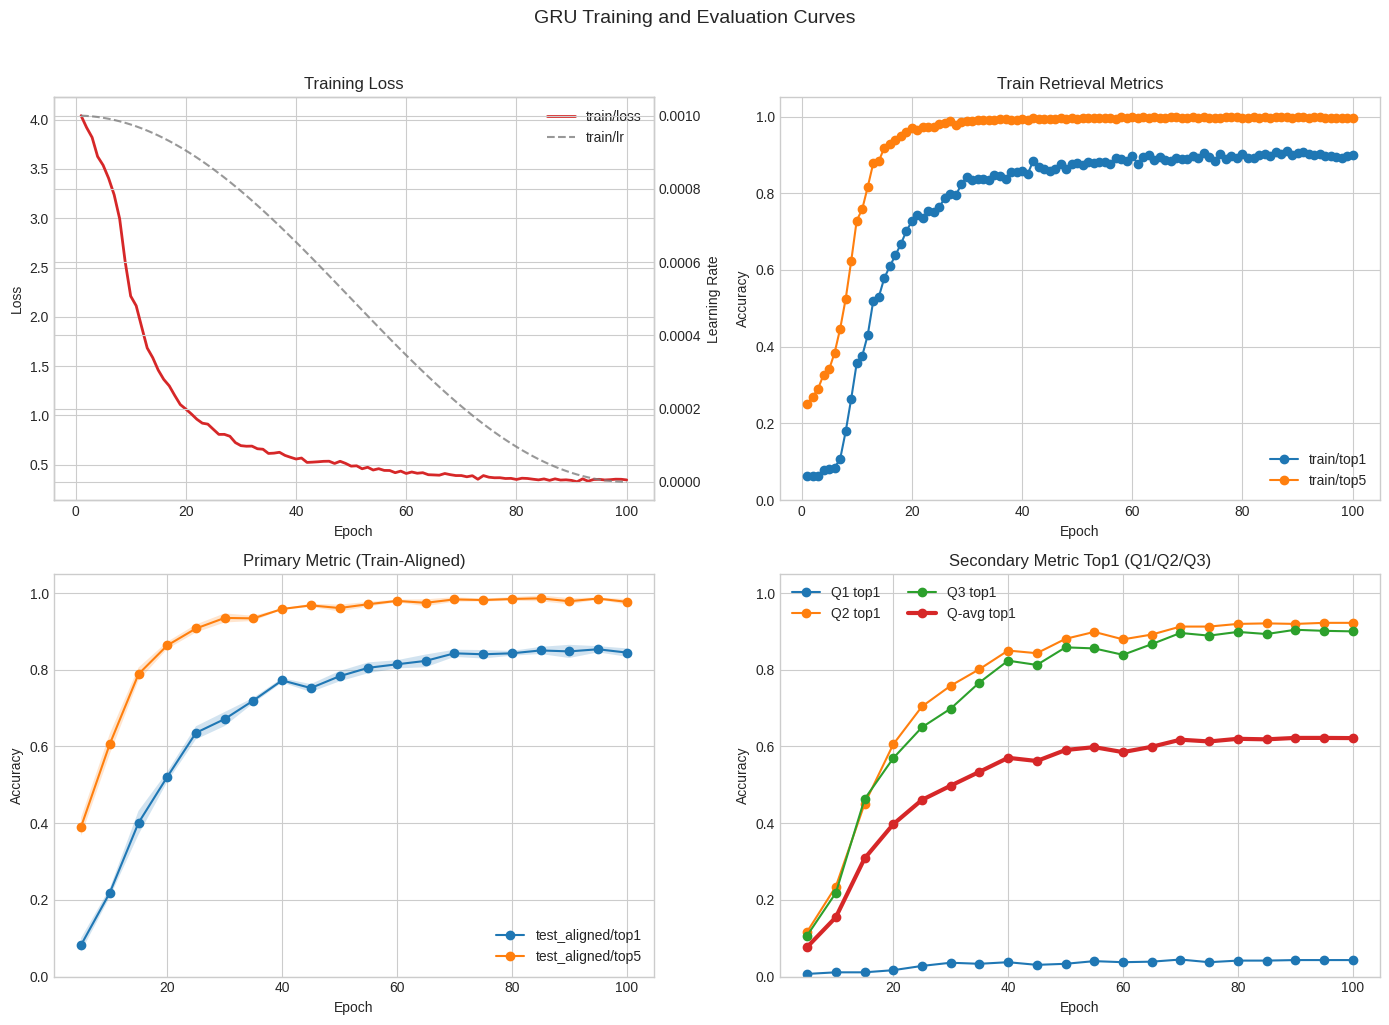

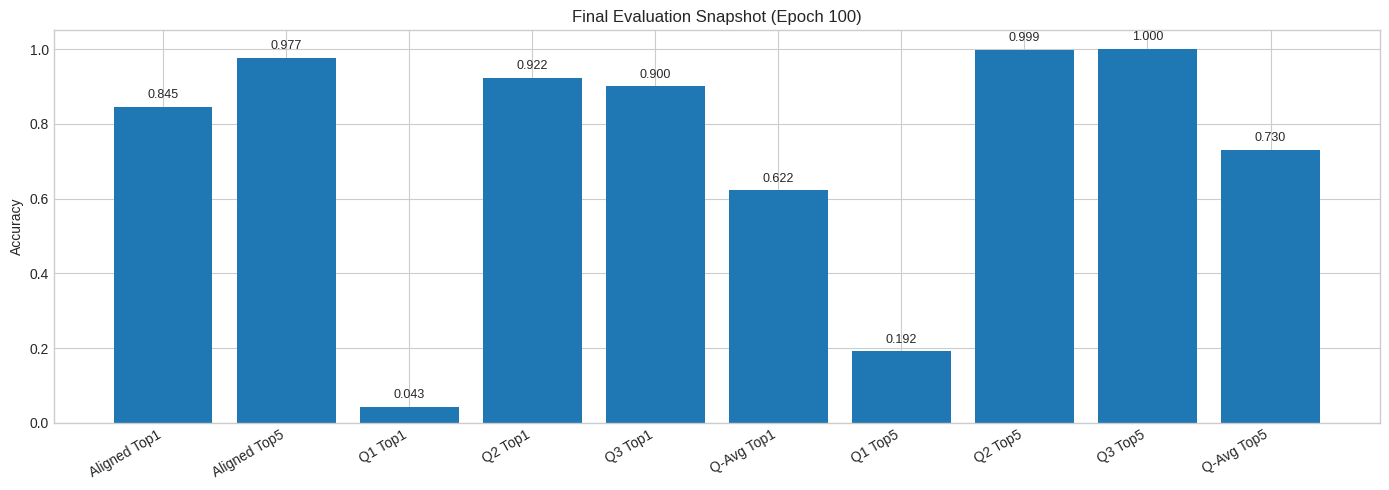

In [22]:
# ── Plots: Training + Primary/Secondary Metrics ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

if "history" not in globals() or not history:
    print("No history found. Run the training cell first.")
else:
    rows = history

    epochs = [r["epoch"] for r in rows]
    train_loss = [r.get("train/loss", np.nan) for r in rows]
    train_top1 = [r.get("train/top1", np.nan) for r in rows]
    train_top5 = [r.get("train/top5", np.nan) for r in rows]
    train_lr = [r.get("train/lr", np.nan) for r in rows]

    eval_rows = [r for r in rows if "test_aligned/top1" in r]
    eval_epochs = [r["epoch"] for r in eval_rows]

    aligned_top1 = [r.get("test_aligned/top1", np.nan) for r in eval_rows]
    aligned_top5 = [r.get("test_aligned/top5", np.nan) for r in eval_rows]
    aligned_top1_std = [r.get("test_aligned/top1_std", 0.0) for r in eval_rows]
    aligned_top5_std = [r.get("test_aligned/top5_std", 0.0) for r in eval_rows]

    q1_top1 = [r.get("test_q1/top1", np.nan) for r in eval_rows]
    q2_top1 = [r.get("test_q2/top1", np.nan) for r in eval_rows]
    q3_top1 = [r.get("test_q3/top1", np.nan) for r in eval_rows]
    qavg_top1 = [r.get("test_q_avg/top1", np.nan) for r in eval_rows]

    q1_top5 = [r.get("test_q1/top5", np.nan) for r in eval_rows]
    q2_top5 = [r.get("test_q2/top5", np.nan) for r in eval_rows]
    q3_top5 = [r.get("test_q3/top5", np.nan) for r in eval_rows]
    qavg_top5 = [r.get("test_q_avg/top5", np.nan) for r in eval_rows]

    plt.style.use("seaborn-v0_8-whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1) Loss and LR
    ax = axes[0, 0]
    ax.plot(epochs, train_loss, color="tab:red", label="train/loss", linewidth=2)
    ax.set_title("Training Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    ax2 = ax.twinx()
    ax2.plot(epochs, train_lr, color="tab:gray", linestyle="--", label="train/lr", alpha=0.8)
    ax2.set_ylabel("Learning Rate")

    # Merge legends from twin axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # 2) Train retrieval
    ax = axes[0, 1]
    ax.plot(epochs, train_top1, marker="o", label="train/top1")
    ax.plot(epochs, train_top5, marker="o", label="train/top5")
    ax.set_title("Train Retrieval Metrics")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.05)
    ax.legend()

    # 3) Primary metric with std bands
    ax = axes[1, 0]
    if eval_epochs:
        at1 = np.array(aligned_top1, dtype=float)
        at5 = np.array(aligned_top5, dtype=float)
        as1 = np.array(aligned_top1_std, dtype=float)
        as5 = np.array(aligned_top5_std, dtype=float)

        ax.plot(eval_epochs, at1, marker="o", label="test_aligned/top1")
        ax.fill_between(eval_epochs, np.clip(at1 - as1, 0, 1), np.clip(at1 + as1, 0, 1), alpha=0.2)

        ax.plot(eval_epochs, at5, marker="o", label="test_aligned/top5")
        ax.fill_between(eval_epochs, np.clip(at5 - as5, 0, 1), np.clip(at5 + as5, 0, 1), alpha=0.2)

    ax.set_title("Primary Metric (Train-Aligned)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.05)
    ax.legend()

    # 4) Secondary metrics across query types
    ax = axes[1, 1]
    if eval_epochs:
        ax.plot(eval_epochs, q1_top1, marker="o", label="Q1 top1")
        ax.plot(eval_epochs, q2_top1, marker="o", label="Q2 top1")
        ax.plot(eval_epochs, q3_top1, marker="o", label="Q3 top1")
        ax.plot(eval_epochs, qavg_top1, marker="o", linewidth=3, label="Q-avg top1")

    ax.set_title("Secondary Metric Top1 (Q1/Q2/Q3)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.05)
    ax.legend(ncol=2)

    fig.suptitle("GRU Training and Evaluation Curves", fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

    # Final snapshot bar chart
    if eval_rows:
        last = eval_rows[-1]
        labels = [
            "Aligned Top1", "Aligned Top5",
            "Q1 Top1", "Q2 Top1", "Q3 Top1", "Q-Avg Top1",
            "Q1 Top5", "Q2 Top5", "Q3 Top5", "Q-Avg Top5",
        ]
        values = [
            last.get("test_aligned/top1", np.nan),
            last.get("test_aligned/top5", np.nan),
            last.get("test_q1/top1", np.nan),
            last.get("test_q2/top1", np.nan),
            last.get("test_q3/top1", np.nan),
            last.get("test_q_avg/top1", np.nan),
            last.get("test_q1/top5", np.nan),
            last.get("test_q2/top5", np.nan),
            last.get("test_q3/top5", np.nan),
            last.get("test_q_avg/top5", np.nan),
        ]

        plt.figure(figsize=(14, 5))
        bars = plt.bar(labels, values)
        plt.ylim(0.0, 1.05)
        plt.ylabel("Accuracy")
        plt.title(f"Final Evaluation Snapshot (Epoch {last['epoch']})")
        plt.xticks(rotation=30, ha="right")

        for b, v in zip(bars, values):
            if not np.isnan(v):
                plt.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

        plt.tight_layout()
        plt.show()